In [1]:
import pwd
from os import getcwd
!nvidia-smi

Tue Mar 31 11:45:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        Off |   00000000:01:00.0 Off |                  N/A |
|  0%   43C    P8             15W /  170W |      32MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch
from torch import nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")


Usando: cuda


In [6]:
from torch.utils.data import Dataset

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337, 0.3064, 0.3171],
                         std=[0.2672, 0.2564, 0.2629])
])

class GTSRBDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]['image'].convert('RGB')
        label = self.data[idx]['label']
        if self.transform:
            image = self.transform(image)
        return image, label

ds = load_dataset("tanganke/gtsrb")
test_dataset = GTSRBDataset(ds['test'], transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
print(f"Test: {len(test_dataset)} imágenes")

Test: 12630 imágenes


In [7]:
class CNNBaseline(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_units*4 * 4 * 4, out_features=256),
            nn.ReLU(),
            nn.Linear(256, output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)
        return x

model = CNNBaseline(input_shape=3, hidden_units=32, output_shape=43).to(device)
model.load_state_dict(torch.load("/home/uno21/models/baseline_cnn.pth", map_location=device))
model.eval()
print("Modelo cargado.")

Modelo cargado.


In [8]:
all_preds = []
all_labels = []

model.eval()
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Predicciones: {len(all_preds)}")

Predicciones: 12630


In [9]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       1.00      0.68      0.81        60
           1       0.93      0.96      0.94       720
           2       0.86      0.95      0.90       750
           3       0.95      0.93      0.94       450
           4       0.99      0.94      0.96       660
           5       0.88      0.90      0.89       630
           6       0.96      0.89      0.93       150
           7       0.94      0.86      0.90       450
           8       0.92      0.96      0.94       450
           9       0.94      0.99      0.96       480
          10       1.00      0.96      0.98       660
          11       0.87      0.90      0.89       420
          12       0.99      0.93      0.96       690
          13       0.95      1.00      0.97       720
          14       0.99      0.93      0.96       270
          15       0.87      0.95      0.91       210
          16       0.95      1.00      0.97       150
          17       0.98    

In [18]:
from pathlib import Path

current_directory_path_object = Path.cwd()
print("Current working directory:", current_directory_path_object)


Current working directory: /tmp/pycharm_project_245/training


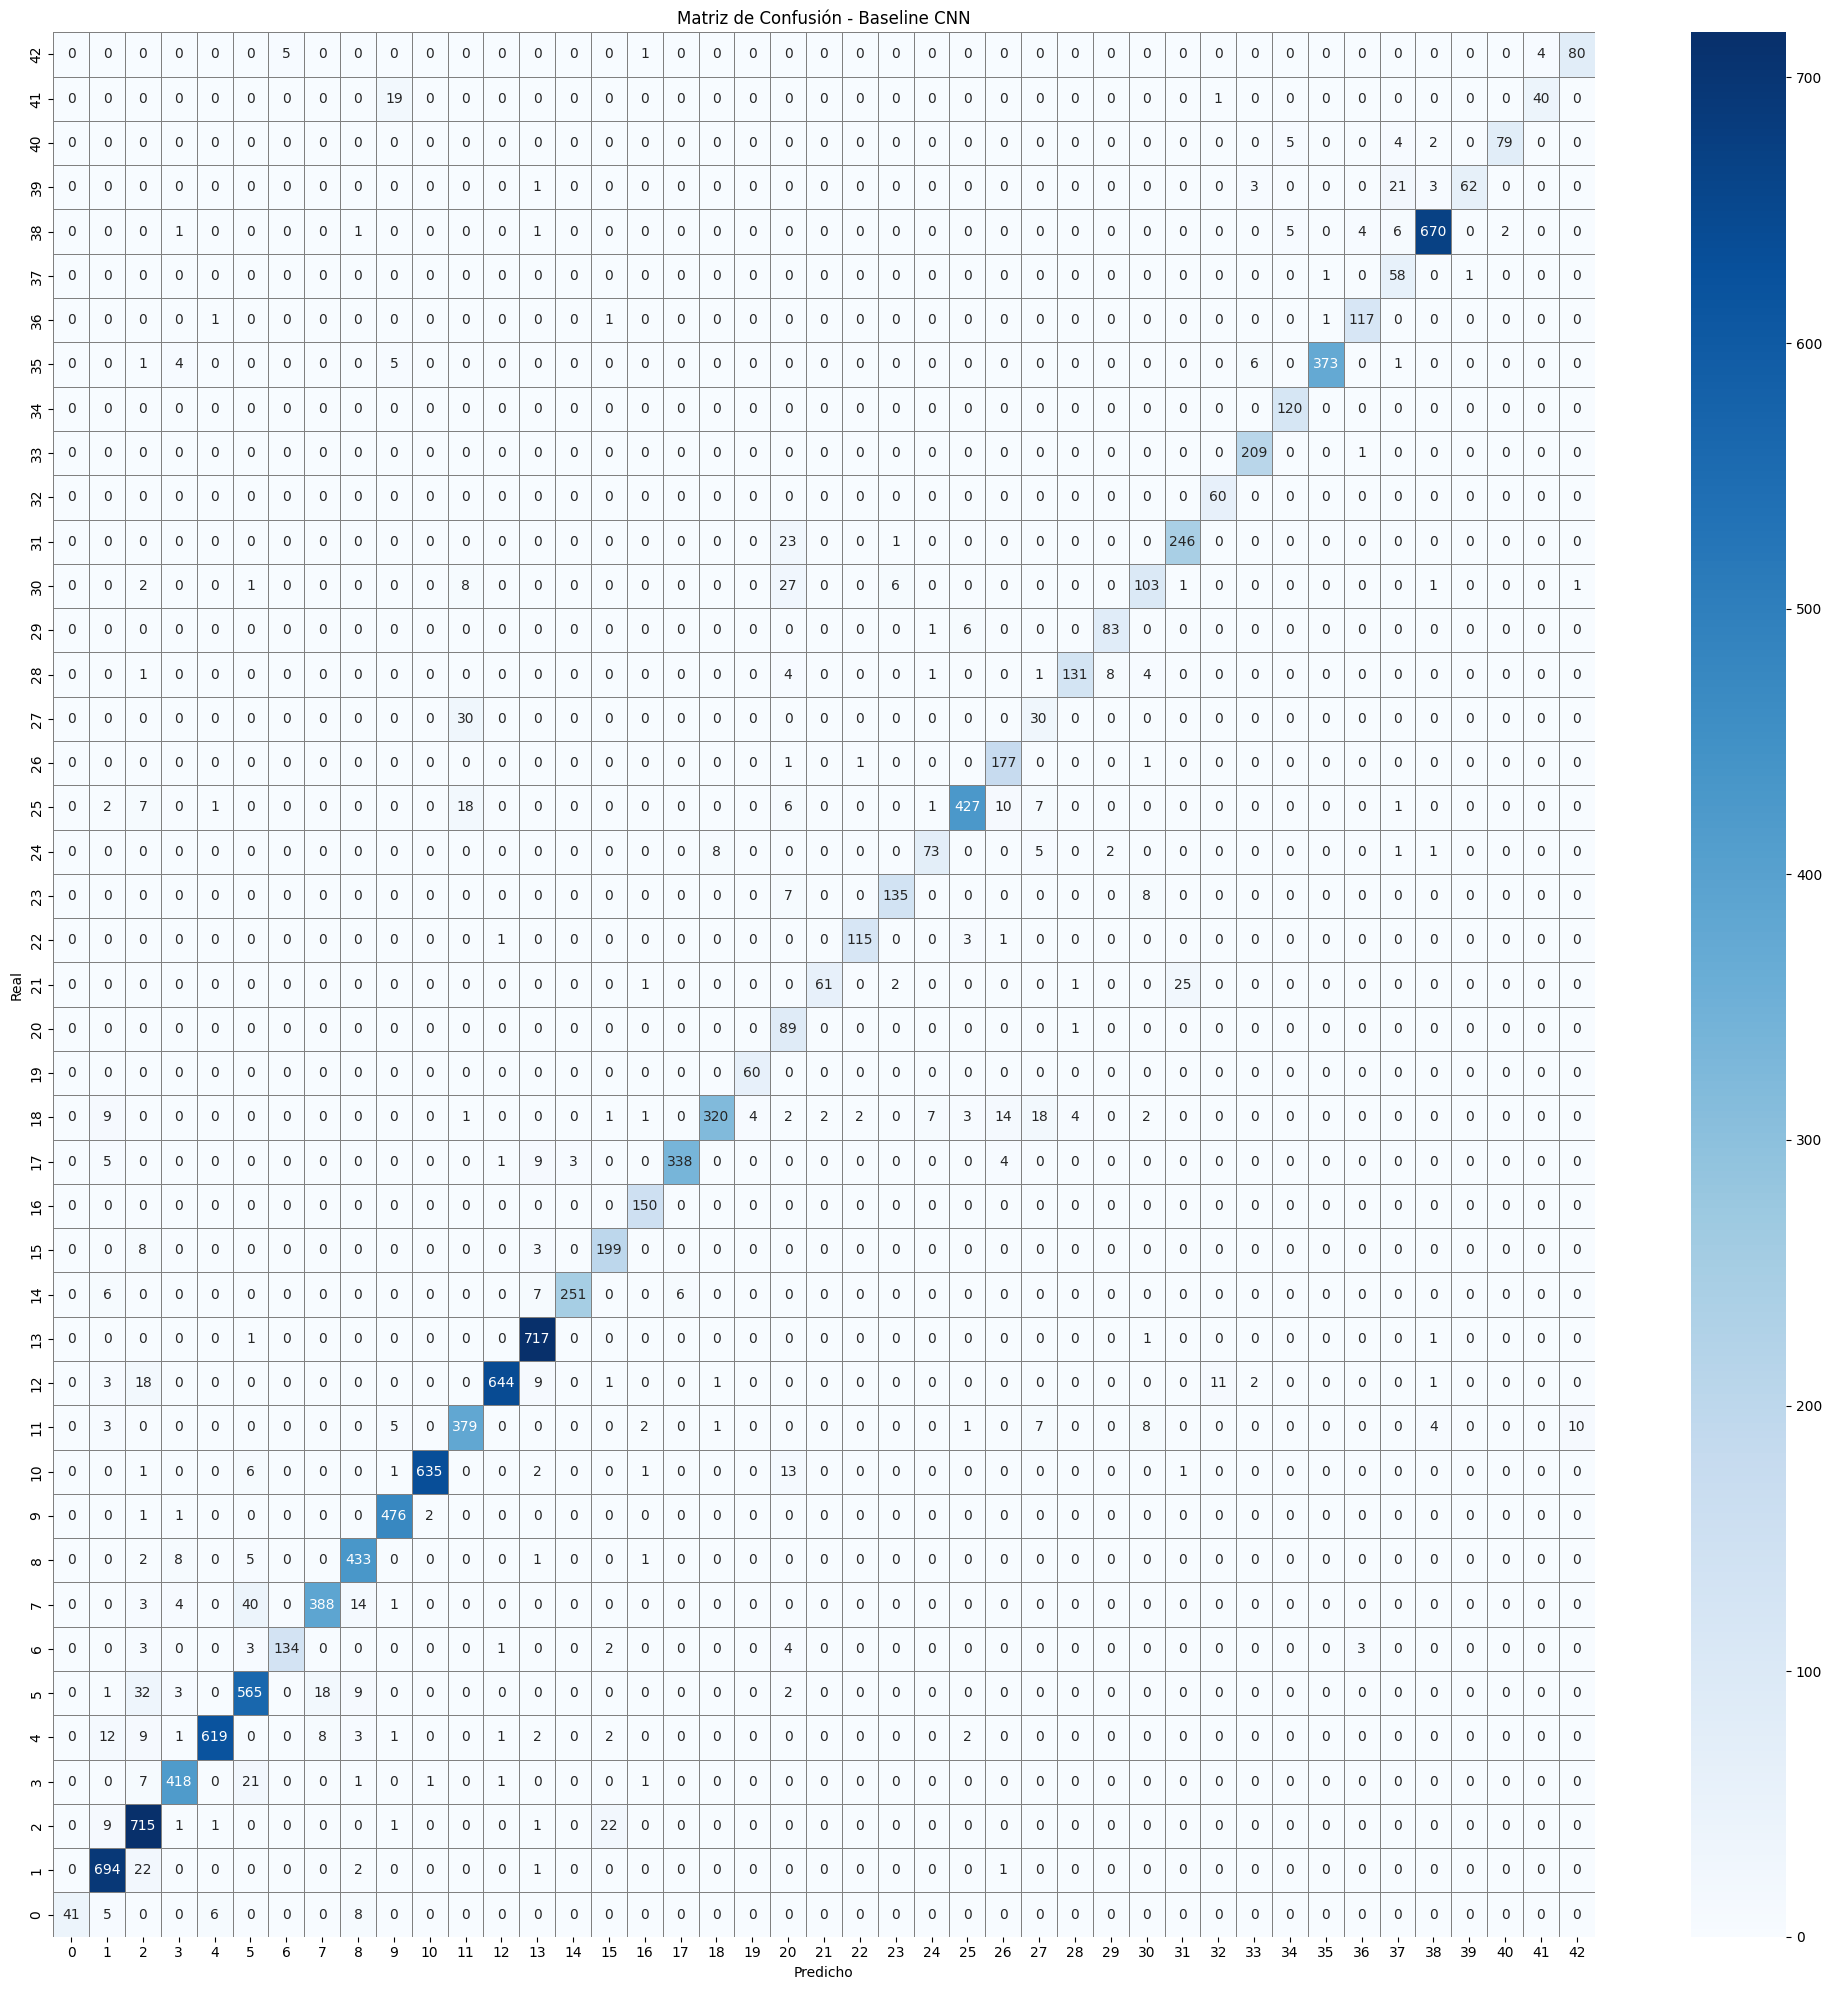

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusión - Baseline CNN')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../training/confusion_matrix.png', dpi=250)
plt.show()